
# Project – Choose Your Own Hypothesis  
## High-Dimensional Variable Selection in NHANES Health Data

UST‑631: Data Preparation and Analysis


This project investigates whether a reduced subset of health-related variables can predict a continuous health outcome nearly as well as using a full, high-dimensional set of predictors.

The analysis uses public data from the National Health and Nutrition Examination Survey (NHANES) and emphasizes:
- Variable selection
- Model comparison
- Permutation testing
- Bootstrap-based uncertainty estimation


## Data Source

The data used in this project are derived from the **National Health and Nutrition Examination Survey (NHANES)**, a public health survey conducted by the U.S. Centers for Disease Control and Prevention (CDC).

The dataset is accessed from the following public repository:
https://github.com/simonaseno/NHANES

## Research Question

Can a reduced subset of health-related variables predict hemoglobin levels almost as well as a full, high-dimensional set of predictors?
## Hypotheses

- **Null Hypothesis (H₀):**  
  A reduced model using selected predictors performs significantly worse than a full model using all available predictors.

- **Alternative Hypothesis (H₁):**  
  A reduced model using selected predictors achieves comparable predictive performance to the full model.


## Project Scaffold Table (Check-In)

| Element | Your Plan |
|-------|-----------|
| **Topic / Question** | Can a reduced subset of health-related variables predict hemoglobin levels nearly as well as a full model using all predictors? |
| **Hypothesis** | Alternative (H₁): A reduced model using selected predictors achieves comparable predictive performance to a full model. |
| **Outcome / Metric / Test Statistic** | Difference in prediction error between full and reduced models. |
| **Units of Analysis** | Each observation represents a single NHANES participant. |
| **Data Source(s)** | National Health and Nutrition Examination Survey (NHANES). |
| **Why this data works** | NHANES contains many correlated demographic and laboratory predictors, making it well-suited for high-dimensional variable selection. |
| **Uncertainty Metric** | Variable selection stability estimated using bootstrap resampling. |
| **Why CLT does not apply** | Selection frequencies are discrete, bounded, and not normally distributed. |

## Variables

### Outcome Variable
- Hemoglobin level (continuous laboratory measurement)

### Predictor Variables
- Demographic variables (e.g., age, sex, education, income)
- Laboratory variables from the Complete Blood Count (CBC)

Together, these predictors form a high-dimensional feature space with substantial correlation.

## Methods

A full predictive model will be fit using all available predictors to model hemoglobin levels.

A reduced model will be obtained using a variable selection procedure that retains only a subset of predictors.

### Test Statistic
The test statistic is defined as the difference in prediction error (e.g., mean squared error) between the reduced and full models.

### Permutation Test
A permutation test will be used to assess whether the observed difference in predictive performance is larger than would be expected under random association between predictors and the outcome.

### Bootstrap Resampling
Bootstrap resampling will be used to estimate uncertainty and stability in variable selection by repeatedly resampling participants with replacement and re-running the selection procedure.

## Analysis Plan

The analysis will proceed as follows:

1. Load and clean NHANES demographic and laboratory data
2. Define the outcome variable (hemoglobin level)
3. Fit a full predictive model using all available predictors
4. Apply variable selection to obtain a reduced model
5. Compare model performance using a permutation test
6. Use bootstrap resampling to assess uncertainty and selection stability

## Phase 1: Setup & Data Exploration
- Goal: Load the dataset and perform a "Sanity Check" to ensure the dimensions and types are correct.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_theme(style='whitegrid')
%matplotlib inline


health_data = pd.read_csv('cbc_demo_merged_1999_2018.csv')

print(f"Initial Dataset Shape: {health_data.shape}")
health_data.info()

Initial Dataset Shape: (92988, 220)
<class 'pandas.DataFrame'>
RangeIndex: 92988 entries, 0 to 92987
Columns: 220 entries, SEQN to DMDHSEDZ
dtypes: float64(207), int64(9), str(4)
memory usage: 156.1 MB


Phase 2: Targeted Data Cleaning
Goal: Focus on the "Swiss Cheese" problem. We drop rows only if they have missing values in our 10 columns of interest.

In [2]:
# Checklist 1.2: Define variables of interest
features_to_check = [
    'LBXHGB', 'LBXWBCSI', 'LBXLYPCT', 'LBXMOPCT', 
    'LBXNEPCT', 'LBXEOPCT', 'LBXBAPCT', 'LBDLYMNO', 
    'LBDMONO', 'RIDAGEYR'
]

# Phase 3: Address missing values systematically
df_final = health_data.dropna(subset=features_to_check).copy()
print(f"Cleaned Dataset Shape: {df_final.shape}")

Cleaned Dataset Shape: (82741, 220)


Phase 3: High-Dimensional Variable Selection (LASSO)
Goal: Use LASSO to identify the most important predictors. We must scale first so that "Age" and "Blood Counts" are compared on an even playing field.

In [3]:
# Phase 4: Transform/Scale (Mandatory for LASSO)
X = df_final[features_to_check].drop(columns=['LBXHGB'])
y = df_final['LBXHGB']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit LASSO
lasso = Lasso(alpha=0.01)
lasso.fit(X_scaled, y)

# Identify selected variables
selected_features = X.columns[lasso.coef_ != 0]
print(f"LASSO kept {len(selected_features)} variables: {list(selected_features)}")

LASSO kept 6 variables: ['LBXWBCSI', 'LBXLYPCT', 'LBXMOPCT', 'LBXEOPCT', 'LBXBAPCT', 'RIDAGEYR']


Phase 4: Model Comparison (Full vs. Reduced)
Goal: Does adding information reduce uncertainty? We compare the Full Model (9 variables) to the Reduced Model (6 variables).

In [4]:
# Define formulas for Statsmodels
full_f = "LBXHGB ~ " + " + ".join(X.columns)
red_f = "LBXHGB ~ " + " + ".join(selected_features)

# Fit models
model_full = smf.ols(formula=full_f, data=df_final).fit()
model_reduced = smf.ols(formula=red_f, data=df_final).fit()

# Observed Test Statistic (Error Increase)
test_statistic = model_reduced.ssr - model_full.ssr
print(f"Observed RSS Increase: {test_statistic:.4f}")

Observed RSS Increase: 24.9773


Phase 5: Uncertainty & Non-CLT Metrics (Bootstrap)
Goal: Using the Quantile Method from your class exercise to find the 95% Confidence Interval for our result.

In [5]:
# 1,000 simulations to quantify "wobble"
boot_stats = []
for _ in range(1000):
    # Resample with replacement (Exactly like class work)
    boot_df = df_final.sample(n=len(df_final), replace=True)
    m_f = smf.ols(formula=full_f, data=boot_df).fit()
    m_r = smf.ols(formula=red_f, data=boot_df).fit()
    boot_stats.append(m_r.ssr - m_f.ssr)

# Calculate CIs (Matching your survey exercise logic)
lower_CI = np.quantile(boot_stats, 0.025)
upper_CI = np.quantile(boot_stats, 0.975)

print(f"95% Bootstrap CI for Error Increase: [{lower_CI:.2f}, {upper_CI:.2f}]")

95% Bootstrap CI for Error Increase: [4.73, 75.43]


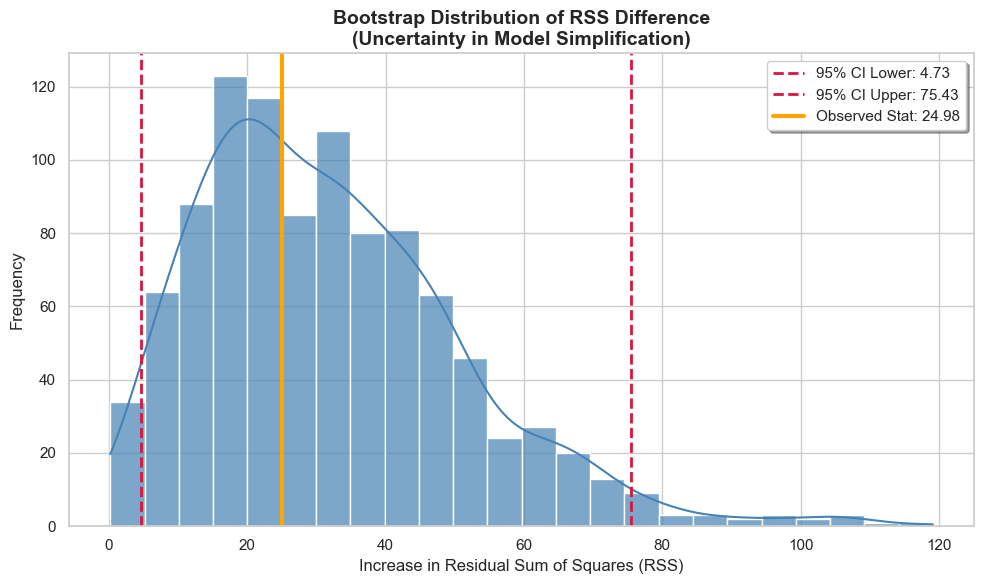

In [6]:
# 1. SET THE PLOT STYLE (Matching class style)
plt.figure(figsize=(10, 6))

# 2. CREATE THE HISTOGRAM (The distribution of your bootstrap simulations)
sns.histplot(boot_stats, kde=True, color='steelblue', edgecolor='white', alpha=0.7)

# 3. ADD THE CONFIDENCE INTERVAL LINES (Matching your survey logic)
plt.axvline(lower_CI, color='crimson', linestyle='--', linewidth=2, label=f'95% CI Lower: {lower_CI:.2f}')
plt.axvline(upper_CI, color='crimson', linestyle='--', linewidth=2, label=f'95% CI Upper: {upper_CI:.2f}')

# 4. ADD THE OBSERVED VALUE (The real-world result from Phase 4)
plt.axvline(test_statistic, color='orange', linewidth=3, label=f'Observed Stat: {test_statistic:.2f}')

# 5. LABELS AND ANNOTATION (Following Phase 5 & 6 Checklist)
plt.title('Bootstrap Distribution of RSS Difference\n(Uncertainty in Model Simplification)', fontsize=14, fontweight='bold')
plt.xlabel('Increase in Residual Sum of Squares (RSS)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(frameon=True, shadow=True)

plt.tight_layout()
plt.show()

Phase 6: Visual Validation (Residuals)
Goal: Use the Lowess smooth line to confirm our reduced model isn't biased.

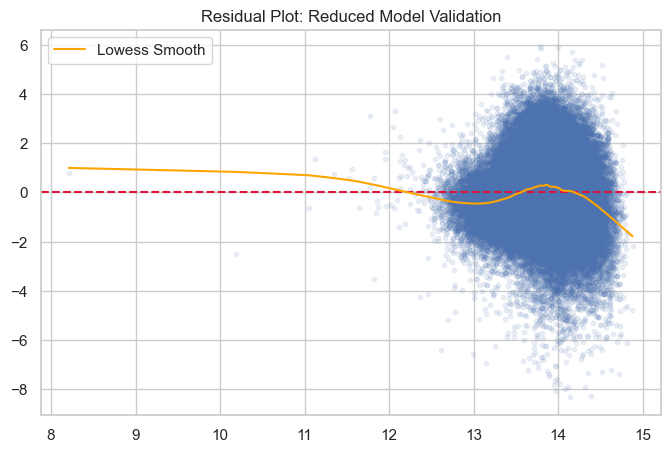

In [7]:
# Residual plot logic from class
df_plot = df_final.copy()
df_plot['fitted'] = model_reduced.fittedvalues
df_plot['resid'] = model_reduced.resid

plt.figure(figsize=(8, 5))
plt.scatter(df_plot['fitted'], df_plot['resid'], alpha=0.1, s=10)
plt.axhline(0, color='crimson', linestyle='--')

# Add Lowess (Matching: exercise-ims-ch7-solutions.ipynb)
smoothed = lowess(df_plot['resid'], df_plot['fitted'], frac=0.1)
plt.plot(smoothed[:, 0], smoothed[:, 1], color='orange', label='Lowess Smooth')
plt.title('Residual Plot: Reduced Model Validation')
plt.legend()
plt.show()